# Etap 6 — Scenariusz przyrostowy (RQ5)

Trzy niezależne łańcuchy przyrostowe (kolejne artykuły dokładane do jednego, narastającego grafu, bez ponownego przetwarzania materiałów już dodanych), każdy oceniony na 4 modelach testowych + Claude Opus 4.6 jako referencja:

| Łańcuch | Temat | Artykułów | Charakter |
|---|---|---|---|
| **Tech (Apple)** | Sukcesja Tima Cooka / Apple / Google / Musk | 8 | umiarkowany overlap encji, gęste specyfikacje |
| **AI Summit** | Konferencja AI Summit PJAIT 2025 (Warszawa) | 6 | dużo osób/opinii, mniej liczb |
| **Wimbledon** | Finał Świątek–Anisimova 2025 | 8 | celowo maksymalny overlap (ten sam wynik meczu w większości artykułów) — stress-test duplikatów |

5 modeli × 3 łańcuchy = 15 obserwacji (jedna ewaluacja na model na łańcuch — stan grafu **po** dodaniu wszystkich artykułów, oceniany względem konkatenacji wszystkich tekstów w łańcuchu). To nie jest progresja krok-po-kroku, tylko porównanie stanu końcowego.

Kontekst wyboru artykułów i pełne obserwacje jakościowe z ręcznego przeglądu trójek są zapisane lokalnie (poza repo, patrz `.gitignore`): `internal/local_notes/konferencja_pl/charakterystyka_artykulow.md` (AI Summit), `internal/local_notes/sport_pl_2/charakterystyka_artykulow.md` (Wimbledon), `internal/local_notes/step_6_incremental_chain/obserwacje_jakosciowe.md` (pełne obserwacje jakościowe, streszczone też na końcu tego notebooka).

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

COLS = ["prompt_key", "ref_position", "position", "id", "title", "model",
        "precision", "recall", "hall", "miss",
        "t_precision", "t_recall", "t_hall", "t_miss",
        "connectivity", "unique_entities", "reference_unique_entities", "ref_ent_diff",
        "self_duplicate_relations", "self_duplicate_rate",
        "merge_new_candidate_count", "merge_dropped_count", "merge_drop_rate"]

df = pd.read_csv("step_6_incremental_chain.csv", header=None, names=COLS)

def short_label(m):
    if "/" in m:
        m = m.rsplit("/", 1)[-1]
    return m

CHAIN_LABELS = {
    "technology/new_graph": "Tech (Apple)",
    "konferencja_pl/new_graph": "AI Summit",
    "sport_pl/new_graph": "Wimbledon",
}
CHAINS = ["Tech (Apple)", "AI Summit", "Wimbledon"]

df["model_short"] = df["model"].apply(short_label)
df["chain"] = df["prompt_key"].map(CHAIN_LABELS)

TOP4 = ["gemma-4-26b-a4b-it", "gemma-4-31b-it", "mistral-small-3.2-24b-instruct", "qwen3-32b"]
MODEL_COLORS = {
    "gemma-4-26b-a4b-it":             "#e41a1c",
    "gemma-4-31b-it":                 "#377eb8",
    "mistral-small-3.2-24b-instruct": "#4daf4a",
    "qwen3-32b":                      "#984ea3",
    "claude-opus-4-6":                "#555555",
}
CHAIN_COLORS = {"Tech (Apple)": "#4878d0", "AI Summit": "#ee854a", "Wimbledon": "#55a868"}

print(f"{len(df)} wierszy | {df['chain'].nunique()} łańcuchy | {df['model_short'].nunique()} modeli (w tym referencja Opus)")
for c in CHAINS:
    print(f"  {c}: {sorted(df[df['chain'] == c]['model_short'].tolist())}")

15 wierszy | 3 łańcuchy | 5 modeli (w tym referencja Opus)
  Tech (Apple): ['claude-opus-4-6', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'mistral-small-3.2-24b-instruct', 'qwen3-32b']
  AI Summit: ['claude-opus-4-6', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'mistral-small-3.2-24b-instruct', 'qwen3-32b']
  Wimbledon: ['claude-opus-4-6', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'mistral-small-3.2-24b-instruct', 'qwen3-32b']


## Tabela zbiorcza — wszystkie 15 obserwacji

In [8]:
NUMERIC = ["precision", "recall", "t_precision", "t_recall", "connectivity"]

overview = df.copy()
overview["chain"] = pd.Categorical(overview["chain"], categories=CHAINS, ordered=True)
model_order = ["claude-opus-4-6"] + TOP4
overview["model_short"] = pd.Categorical(overview["model_short"], categories=model_order, ordered=True)
overview = overview.sort_values(["chain", "model_short"])
overview = overview.rename(columns={"model_short": "Model", "chain": "Łańcuch"})

display(
    overview[["Łańcuch", "Model", "precision", "recall", "t_precision", "t_recall", "connectivity",
              "unique_entities", "reference_unique_entities", "ref_ent_diff",
              "self_duplicate_rate", "merge_drop_rate"]]
    .style
    .background_gradient(subset=NUMERIC, cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["self_duplicate_rate"], cmap="RdYlGn_r", vmin=0, vmax=0.35)  # wysoko = źle, duplikaty przetrwały do grafu
    .background_gradient(subset=["merge_drop_rate"], cmap="Blues", vmin=0, vmax=0.35)  # neutralnie: wysoko = dużo powtórzeń w źródle + spójne frazowanie modelu, nie ocena jakości
    .format({
        "precision": "{:.1%}", "recall": "{:.1%}", "t_precision": "{:.1%}", "t_recall": "{:.1%}",
        "connectivity": "{:.1%}", "self_duplicate_rate": "{:.1%}", "merge_drop_rate": "{:.1%}",
        "unique_entities": "{:.0f}", "reference_unique_entities": "{:.0f}", "ref_ent_diff": "{:+.0f}",
    }, na_rep="—")
    .hide(axis="index")
    .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
)

Łańcuch,Model,precision,recall,t_precision,t_recall,connectivity,unique_entities,reference_unique_entities,ref_ent_diff,self_duplicate_rate,merge_drop_rate
Tech (Apple),claude-opus-4-6,95.8%,94.0%,92.7%,94.4%,93.9%,115,111,+4,4.2%,2.4%
Tech (Apple),gemma-4-26b-a4b-it,91.6%,90.9%,80.9%,64.2%,94.7%,95,115,-20,6.1%,3.0%
Tech (Apple),gemma-4-31b-it,93.1%,87.1%,82.8%,58.2%,92.7%,82,115,-33,6.9%,4.9%
Tech (Apple),mistral-small-3.2-24b-instruct,87.5%,92.7%,71.9%,69.7%,95.2%,126,115,+11,4.4%,14.9%
Tech (Apple),qwen3-32b,91.8%,86.6%,73.9%,60.0%,94.1%,101,115,-14,3.0%,1.5%
AI Summit,claude-opus-4-6,98.7%,95.1%,—,—,92.5%,106,—,—,6.4%,0.6%
AI Summit,gemma-4-26b-a4b-it,99.1%,91.7%,97.3%,69.4%,88.6%,88,106,-18,0.9%,4.3%
AI Summit,gemma-4-31b-it,87.7%,87.7%,96.5%,70.1%,97.6%,84,106,-22,5.3%,3.4%
AI Summit,mistral-small-3.2-24b-instruct,85.9%,91.5%,74.8%,77.7%,81.9%,142,106,+36,1.8%,1.8%
AI Summit,qwen3-32b,81.4%,90.6%,67.8%,76.4%,85.5%,138,106,+32,4.0%,2.2%


## Wykres: Precision / Recall / T-Precision / T-Recall per łańcuch

Tylko 4 modele testowane (referencja Opus pominięta na wykresie — patrz tabela wyżej dla jej własnych wartości Precision/Recall).

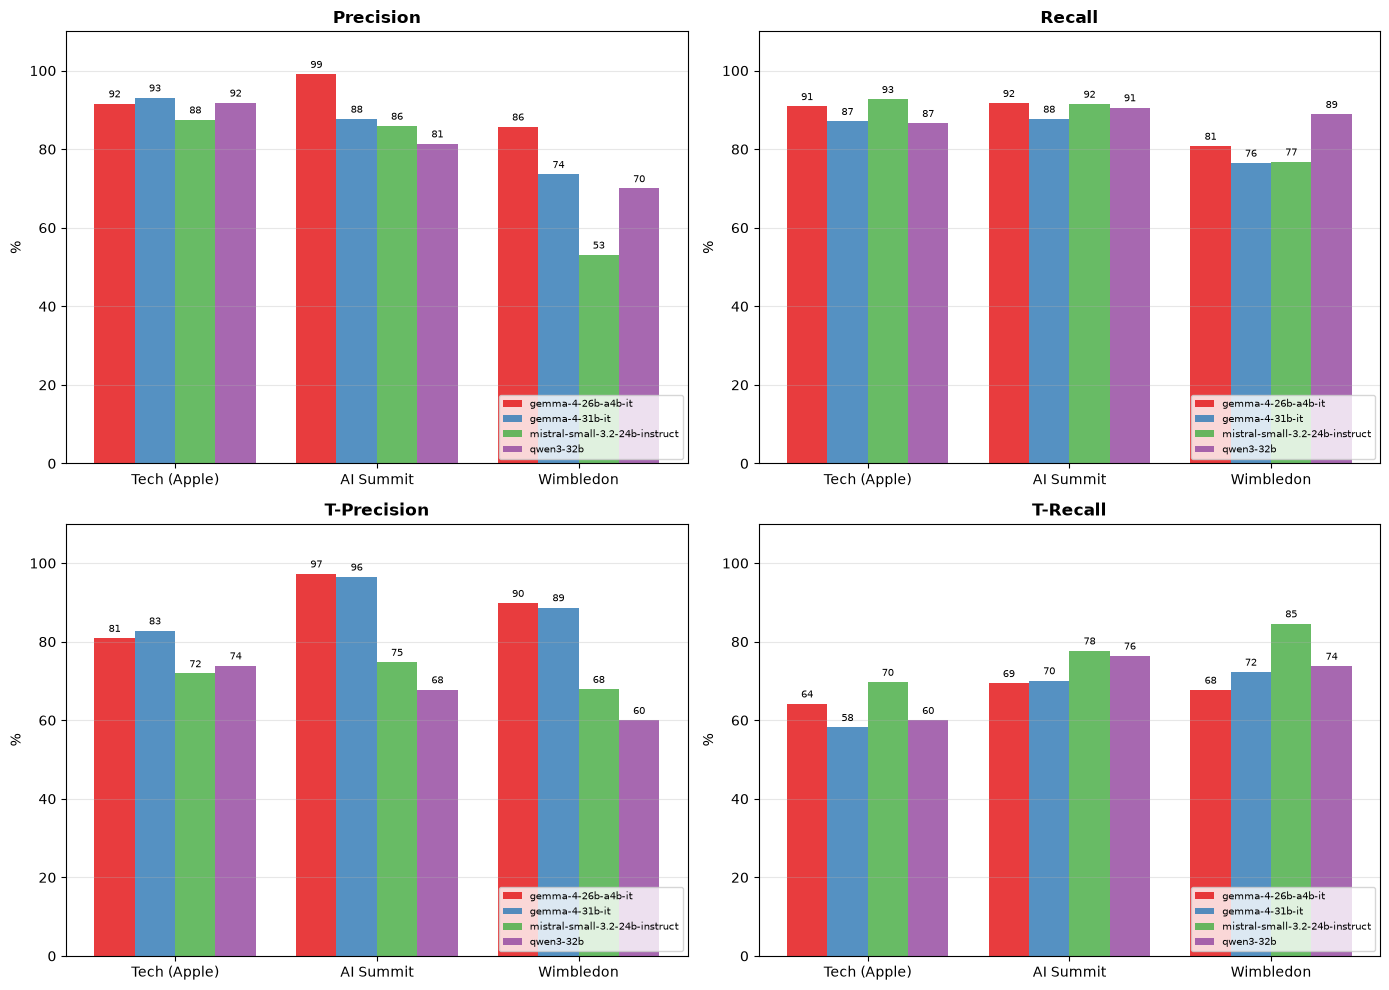

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x = np.arange(len(CHAINS))
w = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

metrics4 = ["precision", "recall", "t_precision", "t_recall"]
mlabels4 = ["Precision", "Recall", "T-Precision", "T-Recall"]

df4 = df[df["model_short"].isin(TOP4)]
agg4 = df4.set_index(["chain", "model_short"])

for ax, metric, mlabel in zip(axes, metrics4, mlabels4):
    for model, offset in zip(TOP4, offsets):
        vals = []
        for chain in CHAINS:
            try:
                vals.append(agg4.loc[(chain, model), metric] * 100)
            except KeyError:
                vals.append(np.nan)
        bars = ax.bar(x + offset * w, vals, w, label=model, color=MODEL_COLORS[model], alpha=0.85)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                        f"{v:.0f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(CHAINS, fontsize=10)
    ax.set_ylim(0, 110)
    ax.set_ylabel("%")
    ax.set_title(mlabel, fontsize=12, fontweight="bold")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(axis="y", alpha=0.3)

# fig.suptitle("Etap 6 — Precision/Recall/T-Precision/T-Recall per łańcuch przyrostowy (4 modele)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Metryki specyficzne dla scenariusza przyrostowego

Różnica liczby unikalnych encji względem Opusa, odsetek semantycznych duplikatów przetrwałych scalanie (self-dup) oraz odsetek kandydackich relacji odrzuconych jako dokładne duplikaty tekstowe (merge drop).

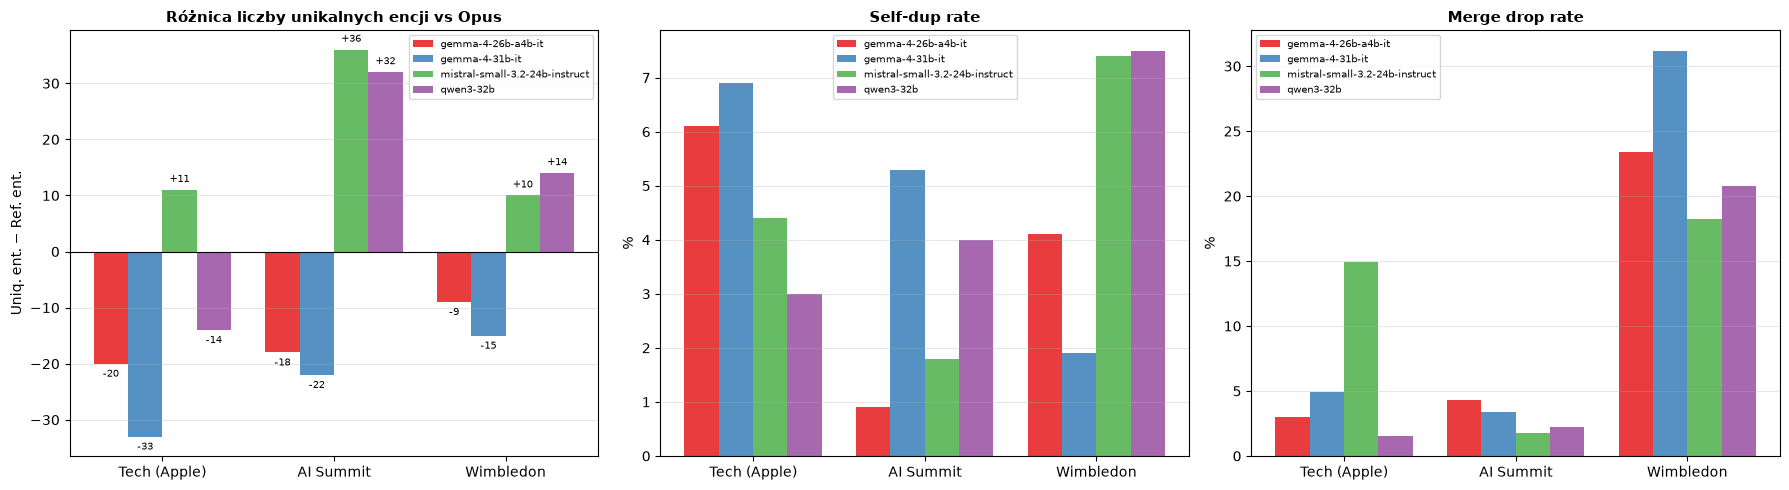

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: różnica liczby unikalnych encji względem Opusa
ax = axes[0]
for model, offset in zip(TOP4, offsets):
    vals = []
    for chain in CHAINS:
        try:
            vals.append(agg4.loc[(chain, model), "ref_ent_diff"])
        except KeyError:
            vals.append(np.nan)
    bars = ax.bar(x + offset * w, vals, w, label=model, color=MODEL_COLORS[model], alpha=0.85)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            va = "bottom" if v >= 0 else "top"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (1 if v >= 0 else -1),
                    f"{v:+.0f}", ha="center", va=va, fontsize=7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(CHAINS, fontsize=10)
ax.set_ylabel("Uniq. ent. − Ref. ent.")
ax.set_title("Różnica liczby unikalnych encji vs Opus", fontsize=11, fontweight="bold")
ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)

# Panel 2: self-dup rate
ax = axes[1]
for model, offset in zip(TOP4, offsets):
    vals = []
    for chain in CHAINS:
        try:
            vals.append(agg4.loc[(chain, model), "self_duplicate_rate"] * 100)
        except KeyError:
            vals.append(np.nan)
    ax.bar(x + offset * w, vals, w, label=model, color=MODEL_COLORS[model], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CHAINS, fontsize=10)
ax.set_ylabel("%")
ax.set_title("Self-dup rate", fontsize=11, fontweight="bold")
ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)

# Panel 3: merge drop rate
ax = axes[2]
for model, offset in zip(TOP4, offsets):
    vals = []
    for chain in CHAINS:
        try:
            vals.append(agg4.loc[(chain, model), "merge_drop_rate"] * 100)
        except KeyError:
            vals.append(np.nan)
    ax.bar(x + offset * w, vals, w, label=model, color=MODEL_COLORS[model], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CHAINS, fontsize=10)
ax.set_ylabel("%")
ax.set_title("Merge drop rate", fontsize=11, fontweight="bold")
ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)

# fig.suptitle("Etap 6 — metryki przyrostowe (duplikaty, kompletność encji)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Ranking modeli per łańcuch (wg T-Precision i T-Recall)

In [11]:
rank_cols = ["precision", "t_precision", "t_recall", "connectivity"]
for chain in CHAINS:
    display(HTML(f"<h4>{chain}</h4>"))
    sub = df4[df4["chain"] == chain]
    r = sub.set_index("model_short")[rank_cols].round(3)
    r = r.reindex(TOP4)
    display(
        r.style
        .background_gradient(subset=rank_cols, cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.1%}" for c in rank_cols})
    )

,precision,t_precision,t_recall,connectivity
model_short,,,,
gemma-4-26b-a4b-it,91.6%,80.9%,64.2%,94.7%
gemma-4-31b-it,93.1%,82.8%,58.2%,92.7%
mistral-small-3.2-24b-instruct,87.5%,71.9%,69.7%,95.2%
qwen3-32b,91.8%,73.9%,60.0%,94.1%


,precision,t_precision,t_recall,connectivity
model_short,,,,
gemma-4-26b-a4b-it,99.1%,97.3%,69.4%,88.6%
gemma-4-31b-it,87.7%,96.5%,70.1%,97.6%
mistral-small-3.2-24b-instruct,85.9%,74.8%,77.7%,81.9%
qwen3-32b,81.4%,67.8%,76.4%,85.5%


,precision,t_precision,t_recall,connectivity
model_short,,,,
gemma-4-26b-a4b-it,85.7%,89.8%,67.7%,75.0%
gemma-4-31b-it,73.6%,88.7%,72.3%,85.3%
mistral-small-3.2-24b-instruct,53.1%,67.9%,84.6%,91.5%
qwen3-32b,70.0%,60.0%,73.8%,87.5%


## Wnioski jakościowe (skrót — pełna wersja w `obserwacje_jakosciowe.md`)

### 1. Luki metryczne odkryte empirycznie

- **Self-dup łapie parafrazy, nie sprzeczności.** Model może zapisać `X pokonała Y` i `X przegrała z Y` jednocześnie — to nie ta sama para znormalizowana embeddingowo jako duplikat (bo "pokonała"/"przegrała" są semantycznie przeciwne, nie synonimami), więc self-dup tego nie złapie. **Ten sam fakt (półfinał Anisimova–Sabalenka) pomylił wszystkie 4 testowane modele, każdy na inny sposób** — najtrudniejszy pojedynczy fakt w całym zestawie Wimbledon.
- **Fragmentacja nazewnictwa encji nie jest łapana przez żaden mechanizm.** `Roland Garros 2020` i `French Open 2020` wygenerowane jako dwie osobne encje tego samego turnieju — ani dokładne scalanie tekstowe, ani self-dup (wymaga tej samej pary encji) tego nie wykrywa.
- **`merge_drop_rate` niedostępne dla grafów sprzed wdrożenia trackingu** (np. wcześniejsza część łańcucha Tech/Apple) — `NULL`, nie zero.

### 2. Powtarzalny artefakt sędziego

Dwie konkretne trójki (`Sofia Kenin`, `Coco Gauff`, obie z tego samego akapitu źródłowego w łańcuchu Wimbledon) dostały błędny werdykt ✕ **w 4 na 4 kolejnych ewaluacjach**, za każdym razem z komentarzem sędziego kończącym się słowem „Supported" — mimo werdyktu przeciwnego. Zbyt regularne na przypadkowy szum LLM; ~2 trójki szumu na ewaluację jako znany, ograniczony artefakt tego zestawu danych.

### 3. Profile błędów per rodzina modeli (spójne między łańcuchami Tech i Wimbledon)

| Model | Charakterystyczny profil |
|---|---|
| **Gemma (26b, 31b)** | Najwyższe T-Precision, ale zawodzi przez **selektywne pomijanie** całych gałęzi treści (np. wątek trenera w artykule retrospektywnym). Rodzinny błąd nazewniczy: obie wersje niezależnie zamieniają „Danielle" → „Daniella" Collins. |
| **Qwen3-32b** | Konsekwentnie najniższe T-Precision. Zamiast pomijać treść spoza zakresu promptu — **wymyśla własne typy relacji**, żeby ją wcisnąć (np. „zawod", „skończyła piłek"). Jedyny model z realną halucynacją całkowicie zmyślonej encji (Federacja Tenisu Francuskiego). |
| **Mistral-small** | Najwyższy Recall/T-Recall kosztem Precision (53,1% na Wimbledon — najniższe w całym badaniu). Systematyczny błąd formatu wyniku (zapisuje „2:0" zamiast realnego wyniku setowego z tekstu). |

**Ciekawy rozjazd metryk:** na łańcuchu Wimbledon T-Precision rankinguje mistrala *wyżej* niż qwena (67,9% vs 60,0%), ale zwykłe Precision rankinguje ich *odwrotnie* (53,1% vs 70,0%) — konkretny przykład tego, że obie rodziny metryk (4.3.1 vs 4.3.2) mierzą różne rzeczy: mistral trafia bliżej tego, co uznał za istotne Opus, mimo że więcej jego pojedynczych trójek nie przechodzi ścisłej weryfikacji zgodności z tekstem źródłowym (głównie przez błędy formatowania, nie przez wybór złych faktów).

### 4. Luki w prompcie `sport_pl` ujawnione dopiero przez nowe typy treści

- Brak kategorii dla osób publicznych spoza sportu → reakcje polityków (Tusk, Duda, Nitras) znikają z grafu. Świadomie zaakceptowane ograniczenie.
- Tylko relacja „trenuje" (czas teraźniejszy), brak formy przeszłej → żaden model nie zapisał poprawnie „był trenerem" dla artykułu retrospektywnego sprzed 10 miesięcy.

### 5. Gęstość grafu zależy od typu treści, nie tylko liczby artykułów

Łańcuch Tech/Apple (specyfikacje produktowe, dużo atrybutów liczbowych na encję) wygenerował graf na tyle duży, że ewaluacja sędziego przekraczała limit czasu (timeout). Łańcuchy AI Summit i Wimbledon (treść skupiona na ludziach/wydarzeniach) dały wyraźnie mniejsze, łatwiejsze do przetworzenia grafy — mimo porównywalnej lub większej liczby artykułów. Ryzyko rozdęcia grafu zależy bardziej od gęstości atrybutów na encję niż od surowej objętości tekstu.